# Names and IDs
 1.Ido Harel - 322531344
 2. Sagi David Horowitz - 211727334

---
# Section 1
---

# I. Naive Bayes (30 pts)

In this part we will test digits classification on the MNIST dataset, using Bernoulli Naive Bayes (a generative model), in contrast to the Multivariate Logistic Regression (a discriminative model) we saw.

The MNIST dataset contains 28x28 grayscale images of handwritten digits between 0 and 9 (10 classes). For mathmatical analysis clarity, and for matching expected API, each image faltten to create a 1D array with 784 elements.

### Loading the MNIST dataset
Load the MNIST data set. The digits dataset is one of datasets scikit-learn comes with that do not require the downloading of any file from some external website. Use

```
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
```

To fetch the original data. Each image is a 28 by 28 pixels in grayscale range [0,255] and the corresponding label is an integer $y\in [0,9]$. Each image should be transformed into a 1D integer array $x\in [0,255]^{784}$.

```
x_train = x_train.reshape(x_train.shape[0], 784)
x_test = x_test.reshape(x_test.shape[0], 784)
```

Divide your data into train and test sets in a 80-20 ration split. And plot a single sample of each digit as the original image, so you get a feeling how the data looks like.

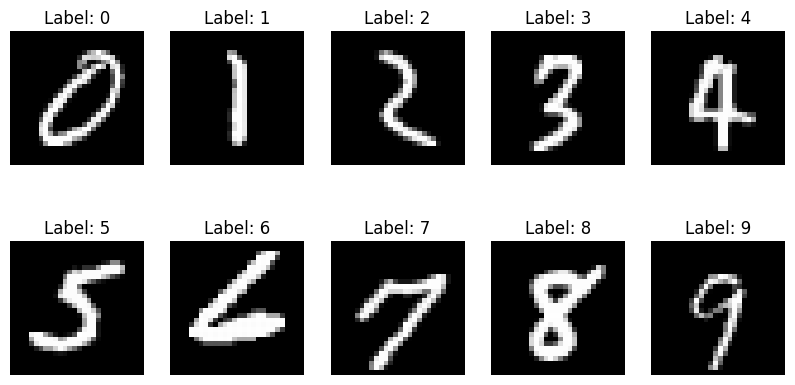

In [1]:
# Implement here
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load data and create a representation of the entire data nit splitted
(x_train_mnist, y_train_mnist), (x_test, y_test) = mnist.load_data()
# Combine all the X's to X
x = np.concatenate((x_train_mnist, x_test), axis=0)
# Combine all the Y's to y
y = np.concatenate((y_train_mnist, y_test), axis=0)
# Change X to 1D
x = x.reshape(x.shape[0], 784)

# Split - do random split of 80-20. picking samples randomally and creates train and test sets.
indices = np.random.permutation(x.shape[0])
samples_num = x.shape[0]
train_samples_num = int(samples_num * 0.8)
training_indices = indices[:train_samples_num]
test_indices = indices[train_samples_num:]
x_train_cut = x[training_indices]
y_train_cut = y[training_indices]
x_test_cut = x[test_indices]
y_test_cut = y[test_indices]

# Plot - example of each class

samples = {}
for i in range(len(y_train_cut)):
  if y_train_cut[i] not in samples:
    samples[y_train_cut[i]] = x_train_cut[i]
  if len(samples) == 10:
    break
  else:
    continue

# Define board of two rows with 5 columns (10 cells) and put the image of j (0-9) at position j.
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for i in range(10):
  axes[i].imshow(samples[i].reshape(28, 28), cmap='gray')
  axes[i].set_title(f'Label: {i}')
  axes[i].axis('off')



### Bernoulli Naive Bayes
If we know how the digits are generated, then we know how to classify them (simply choose the digit class which will maximize the posterior probability) --- but which model should we use for describing the digits generation?

In this part we will try a very simplified model of digits creation (which is obviously not the same as the "real" model), using a Naive Bayes over an underlying Bernoulli distribution --- that is, we will assume that given a digit class, the pixels of the images are the result of independent coin flips, each with its own "head" probability.

Note that since we assume each pixl is either 0 (black) or 1 (white), we will need to adjust (preprocess) our data accrodingly (see below).

So, the model is stated as follows:
$$
\begin{align}
\text{Domain} && x \in \{0,1\}^{784} \\
\text{Prior} && \pi_j = \Pr(y=j) \\
\text{Likelihood} && P_j(x) = \Pr(x | y=j) \\
\end{align}
$$

Where for each $i\in 0\ldots 784$ it holds that the probability of a pixel $i$ to be on given that the digit is $j$ is:
$$
P_{ji}(x_i) = \Pr(x_i | y=j) =
\begin{cases}
p_{ji} & \text{if } x_i=1 \\
1-p_{ji} & \text{if } x_i=0 \\
\end{cases}
$$


#### Question 1
Research the differences between the three types of Naive Bayes classifiers: Bernoulli NB, Multinomial NB, and Gaussian NB.
Describe in your own words what makes each type unique and specify the kind of tasks for which you would prefer each one.

#### Answer 1
Naive Bayes is a classifing algorithm based on probability and Bayes's theorm rules. there is an assumption that the features are independent (which makes the algorithm's name naive bayes).
there are 3 variants of this algorithm:
1. Bernouli NB - this is a Naive Bayes that is designed for binary features only(0 or 1 only). for each feature, the information (cell) inicates presence/absence of the feature (on/off). so the assumption is that the features follow bernouli distribution. The likelihood is computed as a product of Bernoulli probabilities for all features. this version prefered for cases that the features naturally represent binary information (presence/absence, yes/no, etc..).
for example, text classification based on wether a term appears in a document or not. (regardless frequency).
2. Multinomial NB - this version is count-based, meaning each cell indicates the frequency of a feature in the row (the data example). the values (frequencies) are counts and therefore may only by non-negative integers.
The likelihood is computed using a multinomial model, where feature probabilities are raised to the power of their counts.
it can be useful for text classification that considers the frequency of term in document, or spam mail detection (there is an importance to a word's frequency in the mail).
3. Gaussian NB - this version allows features values to be all the continuous numbers. it assumes that each feature follows the Gaussian distribution. each cell represents a feature's value in a row (the row is a data example).
the model calculates likelihood based on the feature's mean and variance of and the Gaussian density function.
this version is best for cases where the features values are continuous.
for example, medical messurements or any other real-life measurements.


#### Question 2
Train a Naive Bayes classifier using the training data and apply predictions on the test data. Use the [sklearn.naive_bayes.BernoulliNB](http://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html) implementation (see the [source code for sklearn.naive_bayes](https://github.com/scikit-learn/scikit-learn/blob/master/sklearn/naive_bayes.py) for details).

Remember we need to preprocess the data in this case such that each pixel would become either black (0) or white (1). For this purpose, use the `binarize` parameter of the `BernoulliNB` function. Set this value to $0$ (this is the default), which in this case would mean every pixel with non-zero value will be set to 1.

1. Plot the confusion matrix of your classifier, as claculated on the test data (it is recommended to use [sklearn.metrics.confusion_matrix](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)). Calculate the total accuracy (fraction of correctly classified images), and summarize the results in your own words.

    A **confusion matrix** for a multi-class classifier is a table that summarizes the performance of the model by comparing the predicted class labels to the true class labels: Each row represents the actual class, and each column represents the predicted class. The diagonal elements indicate the number of correct predictions for each class. Off-diagonal elements show misclassifications (e.g., how many times one class was predicted as another).


2. Plot the mean image of each class (estimated $\hat{p}_{ji}$) and generate one sample of each class (remember, you can do this since this is a generative model). You will need to access the `feature_log_prob_` attribute of the trained model.

3. Think of a way you can find the optimal threshold of the binarization part. **There is no need to actually perform this task --- just describe what you would have done.**

#### Answer 2
Put you answer here...

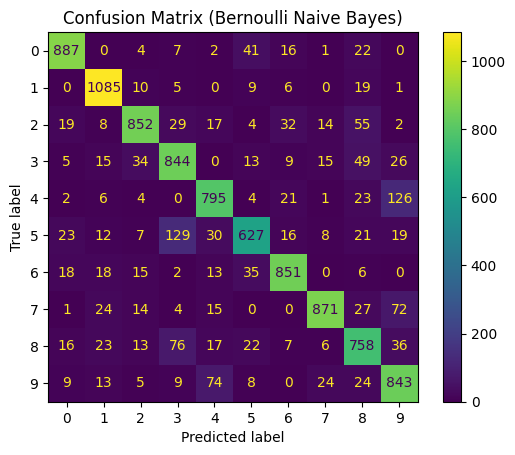


 Total accuracy: 0.8413 


 Mean image of each class: 



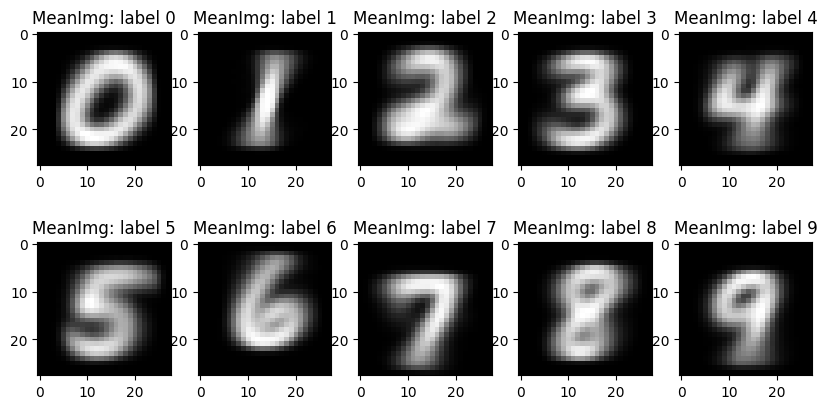


 Generated image of each class: 



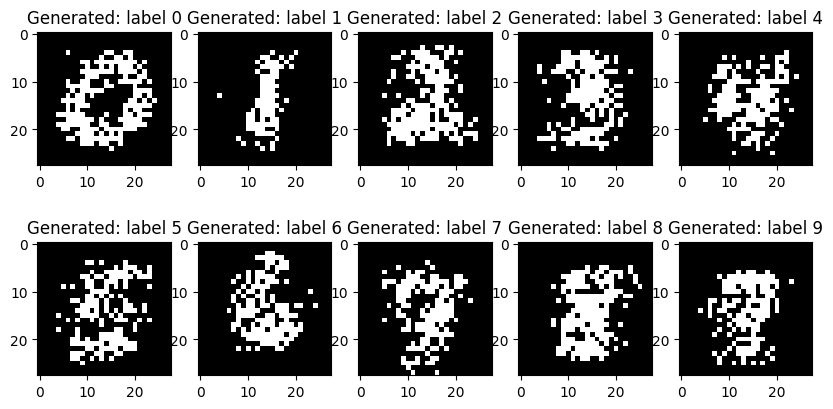

In [2]:
# code goes here
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Train the model and calculate predictions
(x_train_mnist, y_train_mnist), (x_test, y_test) = mnist.load_data()
# Changing x to 1D
x_train_mnist = x_train_mnist.reshape(x_train_mnist.shape[0], 784)
x_test = x_test.reshape(x_test.shape[0], 784)
# Binarize - every pixel with non-zero value will be set to 1.
model = BernoulliNB(binarize=0)
model.fit(x_train_mnist, y_train_mnist)
y_predictions = model.predict(x_test)

# Calculate and represent the confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
disp.plot()
plt.title("Confusion Matrix (Bernoulli Naive Bayes)")
plt.show()

# Print the accuracy
accuracy = accuracy_score(y_test, y_predictions)
print(f"\n Total accuracy: {accuracy} \n")

# Summarize: we can see that the accuracy is around 84% which is very high,
# and it is reflected in the diagonal of the confusion matrix. we can see that the values on the disgonal (success) are much higher then the ones not on it (failure).
# In most cases (84%) the prediction worked well
# continue:

# Represent mean image per class (0-9):
# Mean image - for each class: each feature gets probability of being 1 given the class. according to the probability the drawn pixel is bright (high) or dark (low)

print(f"\n Mean image of each class: \n")

images_matrix = model.feature_log_prob_
images_matrix = np.exp(images_matrix)
# define board of two rows with 5 columns (10 cells) and put the mean age of j (0-9) at position j.
fig,axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for i in range(10):
  axes[i].imshow(images_matrix[i].reshape(28, 28), cmap='gray')
  axes[i].set_title(f'MeanImg: label {i}')
plt.show()

# Represent generated image of each class - similar to the mean image represent

print(f"\n Generated image of each class: \n")

fig,axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for j in range(10):
  sampled_vector_for_j = np.random.binomial(1, images_matrix[j])
  axes[j].imshow(sampled_vector_for_j.reshape(28, 28), cmap='gray')
  axes[j].set_title(f'Generated: label {j}')
plt.show()


# 3.Answer :
# To find the optimal threshold, we can try several (many) binarization thresholds,
# train a model with each one, and evaluate on a validation set.
# then we can Choose the threshold that gives the highest accuracy.








---
# Section 2 - Kaggle competition
---

# Part 2: The Virality Predictor Competition (70 Points)

In this part of the assignment, you will participate in a private Kaggle competition.
**The Goal:** Predict the "Virality Score" (0-100) of short-form videos based on their metadata, text, and visual tags.

Unlike standard datasets, this data mimics raw social media logs. It contains **missing values**, **unstructured text**, and **hidden patterns**.
Simply running a model on the raw data will yield poor results.

**Evaluation Metric:** Mean Squared Error (MSE).
**Competition Link:** [https://www.kaggle.com/t/64ca387e180a4c01bdaf22fc941e51c5]

### EDA - Exploratory Data Analysis (10 pts):
Use any visual tools to present and explain the data. Your answer must include statistics, images, and conclusions.

***Write your code below***


,video_id,uploader_username,author_bio,followers_at_upload,creation_timestamp,video_duration_sec,sound_name,visual_tags,video_transcription_text,user_region
0,4be03b74-5dec-4bf6-8973-fed335c22ee7,johnsonjoshua,Say quality throughout beautiful. Tel Aviv ✨,2307213.0,2025-03-07T20:27:54,NaN,All of Me,NaN,אני לא מאמין שזה קרה לי היום בבוקר,NaN
1,a04a1e6b-b775-4b02-ba41-8672f69712f4,lrobinson,NaN,NaN,2025-03-29T23:54:56,NaN,Funny Laugh 3,Cooking_Kitchen,NaN,NaN
2,a5e6bf43-5a66-4e6f-ac7f-c8f8ae3e4eed,cassandra07,NaN,2885409.0,2025-07-07T14:59:54,45.0,As It Was,Cooking_Kitchen,Those gun court attorney product significant w...,NaN
3,25a73262-d325-423e-ab50-126e7776aa4c,jamesshawn,NaN,NaN,2025-10-31T13:27:46,NaN,Someone Like You,Cooking_Kitchen,Move each left establish.,US
4,8ec4c51b-f954-4bea-811f-fc3de94ddfd4,gabriellecameron,Director allow firm environment. Dollars ✨,2053722.0,2025-10-08T13:50:01,NaN,Drivers License,Cooking_Kitchen,Tree note responsibility defense material.,US


,video_id,virality_score
0,4be03b74-5dec-4bf6-8973-fed335c22ee7,66
1,a04a1e6b-b775-4b02-ba41-8672f69712f4,64
2,a5e6bf43-5a66-4e6f-ac7f-c8f8ae3e4eed,52
3,25a73262-d325-423e-ab50-126e7776aa4c,54
4,8ec4c51b-f954-4bea-811f-fc3de94ddfd4,47



check the missing values ration of each feature:


,missing_ratio
user_region,0.400867
video_transcription_text,0.358200
visual_tags,0.353067
followers_at_upload,0.348800
video_duration_sec,0.348333
author_bio,0.304667
uploader_username,0.000000
video_id,0.000000
creation_timestamp,0.000000
sound_name,0.000000



check unique values per feature:


,num_unique_values
video_id,15000
creation_timestamp,14996
uploader_username,13567
author_bio,9997
followers_at_upload,9722
video_transcription_text,7237
video_duration_sec,56
sound_name,17
visual_tags,5
user_region,4



check for Numeric columns linear correlation to y:

 Correlation between followers_at_upload and virality_score: 0.09882663391716873 


 Correlation between video_duration_sec and virality_score: -0.01768812350979264 


check for Numeric columns connection (may not be linear) to y by groups of values ranges:


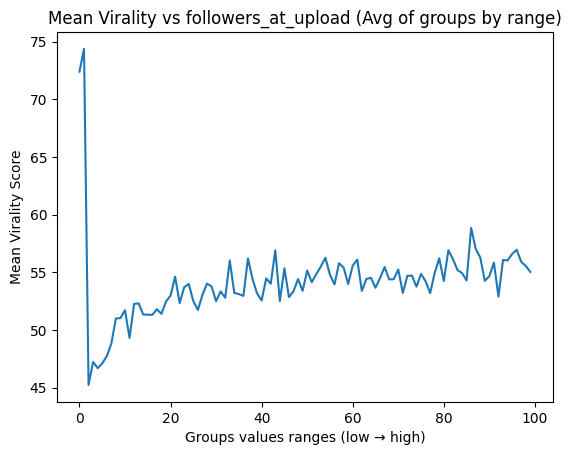

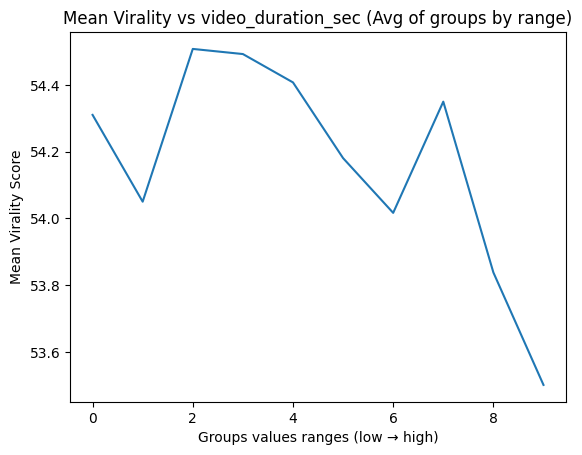


check for categorical features - connection between each feature and y (mean):


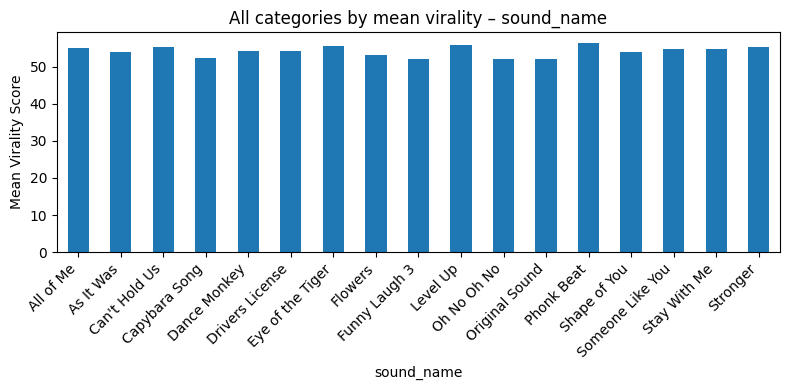

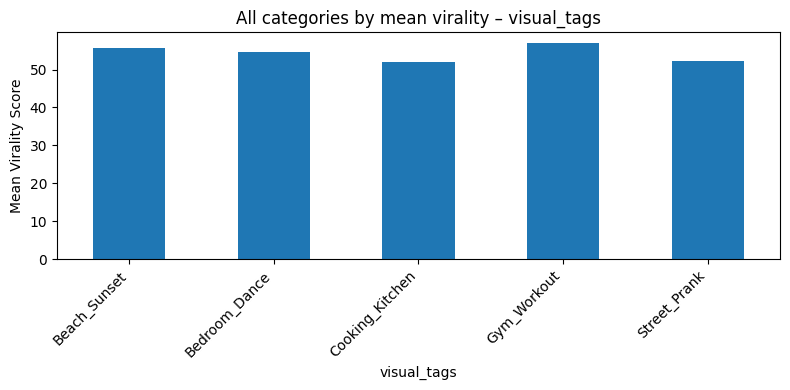

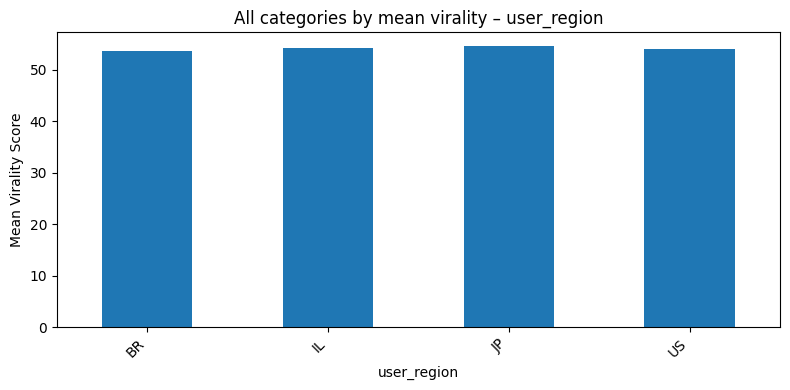


check for text features - length effects the virality?:


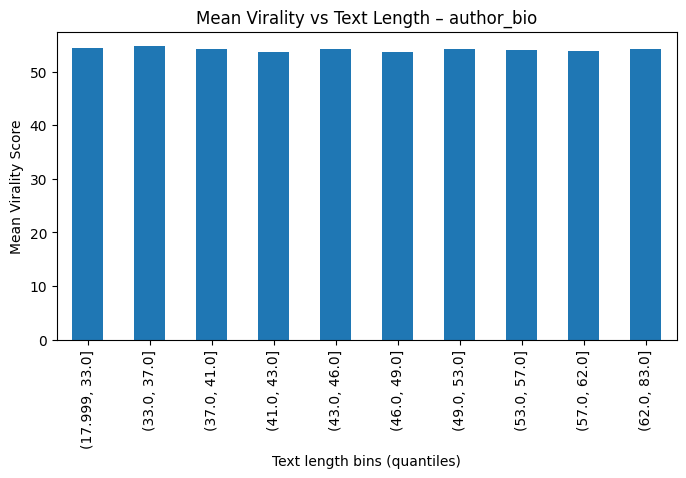

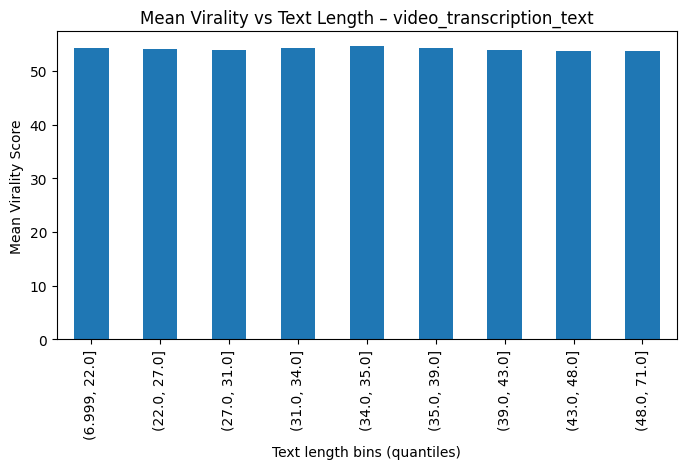


check for uploader_username - those who uploaded at least 5 - more uploads connected to higher variality?


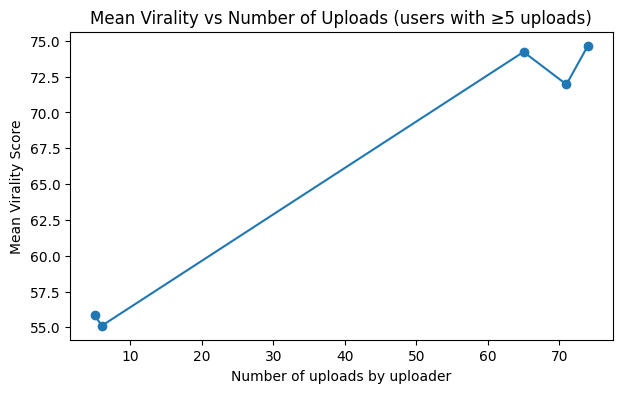


check for creation timestamp - effect of upload day and upload hour on variality:


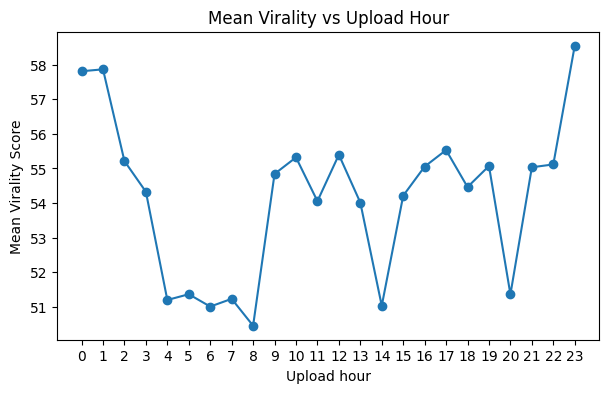

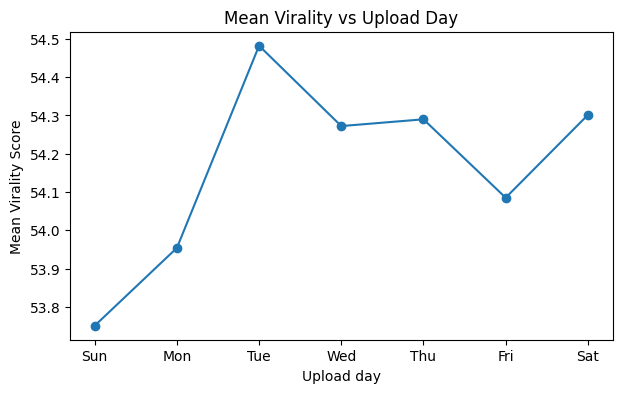


Check mean virality for 2 lowest followers_at_upload groups:
Followers threshold (2% lowest): 488.0
Low followers 2% mean: 73.38383838383838
Rest mean: 53.72173458725183
Counts: 198 9570

Pairwise combinations of TWO CATEGORICAL features
For each pair: show combinations with the largest deviation from global mean

--------------------------------------------------------------------------------
sound_name × visual_tags
Global mean virality: 54.16
--------------------------------------------------------------------------------
Top 3 combinations farthest from the global mean:


,,mean_y,delta_from_global,abs_delta
sound_name,visual_tags,,,
Eye of the Tiger,Gym_Workout,72.462264,18.302264,18.302264
Level Up,Gym_Workout,72.156863,17.996863,17.996863
Phonk Beat,Gym_Workout,71.867257,17.707257,17.707257



--------------------------------------------------------------------------------
sound_name × user_region
Global mean virality: 54.16
--------------------------------------------------------------------------------
Top 3 combinations farthest from the global mean:


,,mean_y,delta_from_global,abs_delta
sound_name,user_region,,,
Phonk Beat,JP,58.171171,4.011171,4.011171
Oh No Oh No,JP,51.170213,-2.989787,2.989787
Phonk Beat,US,57.007692,2.847692,2.847692



--------------------------------------------------------------------------------
visual_tags × user_region
Global mean virality: 54.16
--------------------------------------------------------------------------------
Top 3 combinations farthest from the global mean:


...

,,mean,count,delta_from_global,abs_delta
visual_tags,video_duration_sec,,,,
Gym_Workout,41.0,62.068966,29,7.908966,7.908966
Beach_Sunset,47.0,62.000000,19,7.840000,7.840000
Gym_Workout,20.0,61.956522,23,7.796522,7.796522



--------------------------------------------------------------------------------
CATEGORICAL × NUMERIC: user_region × followers_at_upload
Global mean virality: 54.16
--------------------------------------------------------------------------------
Top 3 combinations farthest from the global mean:


,,mean,count,delta_from_global,abs_delta
user_region,followers_at_upload,,,,
BR,488.0,100.0,1,45.84,45.84
JP,397.0,95.0,1,40.84,40.84
US,382.0,95.0,1,40.84,40.84



--------------------------------------------------------------------------------
CATEGORICAL × NUMERIC: user_region × video_duration_sec
Global mean virality: 54.16
--------------------------------------------------------------------------------
Top 3 combinations farthest from the global mean:


,,mean,count,delta_from_global,abs_delta
user_region,video_duration_sec,,,,
JP,44.0,46.923077,26,-7.236923,7.236923
IL,22.0,60.178571,28,6.018571,6.018571
JP,23.0,59.625000,16,5.465000,5.465000


In [3]:
# Implement here
import pandas as pd

# Load the data
x_train = pd.read_csv("x_train.csv")
y_train = pd.read_csv("y_train.csv")

# View initial data
display(x_train.head())
display(y_train.head())

# Define the y
y = y_train["virality_score"]

# 1.Check the missing values ration of each feature
print("\n" + "="*80)
print("check the missing values ration of each feature:")
missing_ratio_of_each_feature = x_train.isna().mean().sort_values(ascending=False)
missing_all = missing_ratio_of_each_feature.to_frame(name="missing_ratio")
display(missing_all)

# 2.Check unique values per feature to know which can be axamined by categorial values (only small quantity of unique)
print("\n" + "="*80)
print("check unique values per feature:")
unique_per_feature = x_train.nunique(dropna=True).sort_values(ascending=False)
display(unique_per_feature.to_frame(name="num_unique_values"))

# 3.1 Linear connection between numeric features and y
print("\n" + "="*80)
print("check for Numeric columns linear correlation to y:")

for feature in ["followers_at_upload", "video_duration_sec"]:
  x = x_train[feature].dropna()
  y_valid = y.loc[x.index]
  correlation = np.corrcoef(x, y_valid)[0, 1]
  print(f"\n Correlation between {feature} and virality_score: {correlation} \n")

# 3.2 Any connection between numeric features and y.
# Note: followers_at_upload has 9,000 unique values so we split to more groups to have more representing mean of each group
# video_duration_sec has 50 unique values so split to 10 groups is ok

print("\n" + "="*80)
print("check for Numeric columns connection (may not be linear) to y by groups of values ranges:")
for feature in ["followers_at_upload", "video_duration_sec"]:
  x = x_train[feature].dropna()
  y_valid = y.loc[x.index]
  if feature == "followers_at_upload":
      groups_by_range = pd.qcut(x, q=100)
  else:
    groups_by_range = pd.qcut(x, q=10)
  y_mean_for_group = y_valid.groupby(groups_by_range , observed=True).mean()
  plt.figure()
  plt.plot( y_mean_for_group.values)
  plt.title(f"Mean Virality vs {feature} (Avg of groups by range)")
  plt.xlabel("Groups values ranges (low → high)")
  plt.ylabel("Mean Virality Score")
  plt.show()

# 4. Connection between categorial features and y
print("\n" + "="*80)
print("check for categorical features - connection between each feature and y (mean):")

for feature in ["sound_name", "visual_tags", "user_region"]:
  x = x_train[feature].dropna()
  y_valid = y.loc[x.index]
  mean = y_valid.groupby(x).mean()
  plt.figure(figsize=(8, 4))
  mean.plot(kind="bar")
  plt.title(f"All categories by mean virality – {feature}")
  plt.ylabel("Mean Virality Score")
  plt.xlabel(feature)
  plt.xticks(rotation=45, ha="right")
  plt.tight_layout()
  plt.show()

# 5. Text features (features that have many categorial values - not few) check - by length
# Check connection between the length of the text and the y

print("\n" + "="*80)
print("check for text features - length effects the virality?:")

text_features = ["author_bio", "video_transcription_text"]
for feature in text_features:
  x = x_train[feature].dropna()
  y_valid = y.loc[x.index]
  text_length = x.str.len()
  groups_by_range = pd.qcut(text_length, q=10, duplicates="drop")
  mean_y = y_valid.groupby(groups_by_range, observed=True).mean()
  plt.figure(figsize=(8, 4))
  mean_y.plot(kind="bar")
  plt.title(f"Mean Virality vs Text Length – {feature}")
  plt.xlabel("Text length bins (quantiles)")
  plt.ylabel("Mean Virality Score")
  plt.show()

#6. Check for uploader_username feature:
# From those who uploaded at least 5 - more uploads connected to higher variality?
print("\n" + "="*80)
print("check for uploader_username - those who uploaded at least 5 - more uploads connected to higher variality?")

uploads_per_user = x_train["uploader_username"].value_counts()
multi_uploaders = uploads_per_user[uploads_per_user >= 5]
x_train_multi = x_train[x_train["uploader_username"].isin(multi_uploaders.index)]
y_multi = y.loc[x_train_multi.index]

upload_counts = x_train_multi["uploader_username"].value_counts()
num_uploads = x_train_multi["uploader_username"].map(upload_counts)

mean_by_uploads = y_multi.groupby(num_uploads).mean()

plt.figure(figsize=(7,4))
plt.plot(mean_by_uploads.index, mean_by_uploads.values, marker="o")
plt.xlabel("Number of uploads by uploader")
plt.ylabel("Mean Virality Score")
plt.title("Mean Virality vs Number of Uploads (users with ≥5 uploads)")
plt.show()


#7. Check for creation timestamp - the affect of upload day and the affect of upload hour on variality

print("\n" + "="*80)
print("check for creation timestamp - effect of upload day and upload hour on variality:")


timestamps = pd.to_datetime(x_train["creation_timestamp"], errors="coerce").dropna()
y_valid = y.loc[timestamps.index]

hour = timestamps.dt.hour
mean_by_hour = y_valid.groupby(hour).mean()
plt.figure(figsize=(7,4))
plt.plot(mean_by_hour.index, mean_by_hour.values, marker="o")
plt.xticks(range(24))
plt.xlabel("Upload hour")
plt.ylabel("Mean Virality Score")
plt.title("Mean Virality vs Upload Hour")
plt.show()

day = timestamps.dt.dayofweek
day_sun_first = (day + 1) % 7

mean_by_day = y_valid.groupby(day_sun_first).mean()
day_names = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

plt.figure(figsize=(7,4))
plt.plot(range(7), mean_by_day.reindex(range(7)).values, marker="o")
plt.xticks(range(7), day_names)
plt.xlabel("Upload day")
plt.ylabel("Mean Virality Score")
plt.title("Mean Virality vs Upload Day")
plt.show()


# Added checks after initial results:

# 8. Checks if as the graph shows, the 2 groups with lowest followers_at_upload value, actually acheive much higher mean.
# Lowest 2 in division of 100 groups = lowest 2% of data

print("\n" + "="*80)
print("Check mean virality for 2 lowest followers_at_upload groups:")

x = x_train["followers_at_upload"].dropna()
y_valid = y.loc[x.index]

threshold = x.quantile(0.02)
print("Followers threshold (2% lowest):", threshold)


low_followers = y_valid[x <= threshold]
rest = y_valid[x > threshold]

print("Low followers 2% mean:", low_followers.mean())
print("Rest mean:", rest.mean())
print("Counts:", len(low_followers), len(rest))


# Checks of effect 2 features combintaion on y:

numeric_features = ["followers_at_upload", "video_duration_sec"]
categorical_features = ["sound_name", "visual_tags", "user_region"]

# 9. Check of each combination of 2 categorial features:
global_mean = y.mean()


print("\n" + "="*80)
print("Pairwise combinations of TWO CATEGORICAL features")
print("For each pair: show combinations with the largest deviation from global mean")

for i in range(len(categorical_features)):
  for j in range(i+1, len(categorical_features)):
    category1 = categorical_features[i]
    category2 = categorical_features[j]

    print("\n" + "-"*80)
    print(f"{category1} × {category2}")
    print(f"Global mean virality: {global_mean:.2f}")
    print("-"*80)

    x = x_train[[category1, category2]].copy()
    x["y"] = y
    x = x.dropna(subset=[category1, category2, "y"])
    combination_mean = x.groupby([category1, category2])["y"].mean()
    global_mean = y.mean()
    result = combination_mean.to_frame("mean_y")
    result["delta_from_global"] = result["mean_y"] - global_mean
    result["abs_delta"] = result["delta_from_global"].abs()
    print("Top 3 combinations farthest from the global mean:")
    display(result.sort_values("abs_delta", ascending=False).head(3))


# 10. Check for each combination of categorial feature and numeric feature:

print("\n" + "="*80)
print("Pairwise combinations of CATEGORICAL × NUMERIC features")
print("For each pair: show combinations with the largest deviation from global mean")

for categorical_feature in categorical_features:
  for numeric_feature in numeric_features:

    print("\n" + "-"*80)
    print(f"CATEGORICAL × NUMERIC: {categorical_feature} × {numeric_feature}")
    print(f"Global mean virality: {global_mean:.2f}")
    print("-"*80)

    x = x_train[[categorical_feature, numeric_feature]].copy()
    x["y"] = y
    x = x.dropna(subset=[categorical_feature, numeric_feature, "y"])

    result = x.groupby([categorical_feature, numeric_feature])["y"].agg(["mean", "count"])
    result["delta_from_global"] = result["mean"] - global_mean
    result["abs_delta"] = result["delta_from_global"].abs()

    print("Top 3 combinations farthest from the global mean:")

    display(result.sort_values("abs_delta", ascending=False).head(3))







In [4]:
# Explain here
# The train data contains 15000 videos and their features, and the goal is to predict virality score 0-100.
# We made (above) many checks and attempts to learn about the data structure (features types, missing values, etc..)
# and about the data patterns (meaning of each feature, meanings of features combinations, etc..)
# We"ll explain all the chacks we made here:
# 1. We checked the missing values ratio of every feature, in order to know which part of the data is missing,
# if so, and take it into consideration during the pre-process.
# As result, we saw that there are several features with a decent percentage of missing values (30-40%):
# user region, video_transcription_text, visual_tags, followers_at_upload, video_duration_sec, author_bio
# Some of these are numerical features some categorical, and some free text features.
#2. We checked unique values per feature, in order to determine which of the textual features are
# actually categorical (small set of options) and which are free-text features.
# The categorical features: sound_name, visual_tags, user_region.
# The rest: author_bio, uploader_username, video_transcription_text,video_id,creation_timestamp.
# In our opinion video_id (15000 unique values) is not relevant to the model (uniqe),
# and uploader_username, creation_timestamp are relevant but they are not pure-textual features,
# and we"ll make unique tests for some of their characteristics (check 6 and 7).
# The pure-free-textual features are author_bio, video_transcription_text.
# While pre-processing we"ll know to use the one-hot only at categorical features,
# and give other care to the textual features (one-hot will make too large set of features - overfitt)
# 3.1. We checked the linear correlation between numerical features and the y (virality_score),
# in order to see if there is a simple linear relationship that can be directly used by the model.
# We focused on the numerical features: followers_at_upload and video_duration_sec.
# As a result, we saw that both correlations are very weak (close to 0),
# meaning that a linear relation does not explain the data well.
# This result indicates that we should not rely on linear models only.
# 3.2. Since the linear correlation was weak, we checked if there is a non-linear connection
# between the numerical features and the virality score.
# To do that, we grouped the numerical values into range-based groups and calculated
# the mean virality score for each group.
# This check revealed some non-monotonic patterns, especially for followers_at_upload,
# which suggested that extreme of y (highest) are actually reached when the followers_at_upload
# is at its the lowest 2% of values (first two groups of 100).
# This insight led us to explicitly giving attention to the lowest values of followers_at_upload in the model
# 4. We checked the relationship between categorical features and the y.
# For each categorical feature (sound_name, visual_tags, user_region),
# we calculated the mean virality score for each category and visualized the results.
# We observed that there are no clear differences between categories,
# meaning that each of these features by themselves don't have a large influance on y.
# Therefore, we will check their influance in combinations of features (checks 9 and 10).
# 5. We checked the relationship between the length of text features to the virality.
# The result showed that there is no such connection, which implies that we should look at the text's content and not structure.
# The preprocess will include "subjects" calculation and each text's connection to the subjects,
# that so we will give importance to the content and yet not overfit the model with thousands of subjects.
# 6. We examined the uploader_username behavior by analyzing the relationship between the number of uploads per uploader_username and the y result.
# We focused on uploaders with at least 5 videos, in order to reduce noise from single-upload users.
# The analysis showed a trend in which uploaders with more videos tend to achieve
# higher average virality scores.
# This suggests that creator experience or audience familiarity may play a role,
# and therefore we decided to include a feature representing the number of uploads
# per uploader in the model during pre-processing.
# We think it should consider this feature rather then the username.
# 7. We analyzed the creation_timestamp feature to understand temporal effects.
# Specifically, we checked the influence of upload hour and upload day on virality.
# The results showed moderate variations across hours and days,
# with some hours (mainly night) showing higher average virality and some days () showing higher virallity.
# Although the effect is not very strong, it is consistent enough to justify
# extracting time-based features: upload_day, upload_hour from the timestamp rather than the timestamp itself.
# 8. We checked the fact that at #3 it looks like (in the graph) the extreme of y (highest) are actually reached when the followers_at_upload
# is at its lowest 2% of values (first two groups of 100). we saw that the data supports the graph,
# and as mentioned above it"ll be taken into consideration while pre-processing.
# 9. We examined pairwise combinations of categorical features
# in order to detect interaction that effects the virality (y) that doesn't appear when analyzing each feature separately.
# The analysis revealed that certain combinations of sound_name and visual_tags
# (for example, Gym_Workout combined with specific sounds like Eye of the Tiger)
# produce significantly higher virality scores than the y global average.
# This indicates that interactions between categorical features are important,
# and so the use of models that can naturally capture such interactions.
# 10. We examined all the combinations of categorical and numerical features
# to check whether specific numerical values behave differently under certain categorical contexts.
# The results showed that high virality values may occur when a categorical feature is combined with a numerical,
# but we must say that some of the combinations appeared only once in the data, and
# it can explain the high results,
# but  some of the combinations which appear more times in the data,
# got high virality score as well (like visual_tags and	video_duration_sec).
# This further supports the presence of non-linear and interaction-driven patterns,
# and reinforces the decision to use non-linear models and carefully designed pre-processin.




### Preprocessing (25 pts):
Describe in detail what did you do in the preprocessing phase and why you did it.

***Write your code below***

In [5]:
# Implement here
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from scipy import sparse
import re
import pandas as pd
import numpy as np


x = x_train.copy()
y = y_train["virality_score"]

# 1.Fill missing for numeric, categorial, text features
x["followers_at_upload"] = x["followers_at_upload"].fillna(x["followers_at_upload"].median())
x["video_duration_sec"] = x["video_duration_sec"].fillna(x["video_duration_sec"].median())

# user_region is taken care next
categorical_with_missings = ["visual_tags"]
for feature in categorical_with_missings:
  x[feature] = x[feature].fillna(f"unknown_{feature}")


# author_bio - the suffix(last token) of author_bio implies the user_region
# completes missing "user_region" values with a likely region, by "author_bio"'s last token.
token_pat = re.compile(r"[^\W_]+", flags=re.UNICODE)
def last_token(s):
    if pd.isna(s):
        return ""
    tokens = token_pat.findall(s)
    if len(tokens) == 0:
        return ""
    return tokens[-1].lower()
author_bio_suffixes = { }
for bio, region in zip(x["author_bio"], x["user_region"]):
    if pd.isna(region):
      continue

    suffix = last_token(bio)
    if suffix == "":
      continue
    region_key = region #if not pd.isna(region) else "NaN"

    if suffix not in author_bio_suffixes:
        author_bio_suffixes[suffix] = {}

    author_bio_suffixes[suffix][region_key] = author_bio_suffixes[suffix].get(region_key, 0) + 1

# suffix -> [[freq, region1], [freq, region2], ...]
author_bio_suffixes_list = {
    suf: [[cnt, reg] for reg, cnt in sorted(reg_dict.items(), key=lambda x: x[1], reverse=True)]
    for suf, reg_dict in author_bio_suffixes.items()
}
# it seems that suffix that have more than 50 frequencies are indicative
filtered = {}
for k, v in author_bio_suffixes_list.items():
    if k != "" and v[0][0] > 50:
        filtered[k] = v

filtered_for_processing = {suf: v[0][1] for suf, v in filtered.items()}

for idx, row in x[["user_region", "author_bio"]].iterrows():
    if pd.isna(row["user_region"]):
        suffix = last_token(row["author_bio"])
        if suffix in filtered_for_processing:
            x.at[idx, "user_region"] = filtered_for_processing[suffix]

x["user_region"] = x["user_region"].fillna("unknown_user_region")


# For text features - empty string " " instead of NA - when create subject, empty string will represent 0 connection to the subject
x["author_bio"] = x["author_bio"].fillna("").astype(str)
x["video_transcription_text"] = x["video_transcription_text"].fillna("").astype(str)

# 2. Add the 2% feature to represent the effect of the lowest 2% of followers_at_upload on the y
# Each sample who is in the lower 2% gets 1, other 0. by threshold
threshold = x["followers_at_upload"].quantile(0.02)
x["followers_at_upload_low_2_percent"] = (x["followers_at_upload"] <= threshold).astype(int)

# 3. Timestamp's upload hour and upload day as features themselves (showed the connection to y at the EDA)
timestamp_info = pd.to_datetime(x["creation_timestamp"], errors="coerce")
hour = timestamp_info.dt.hour
day = timestamp_info.dt.dayofweek
# The representation: for each hour/day, represent by its location on the unit circle. that can ensure the closeness between 0 to 23 for example
# (sin,cos) represents the location and shows which hours/ days are truly close
# regular numbers won't cover this
hour_sin = np.sin(2 * np.pi * hour / 24.0)
hour_cos = np.cos(2 * np.pi * hour / 24.0)
day_sin  = np.sin(2 * np.pi * day / 7.0)
day_cos  = np.cos(2 * np.pi * day / 7.0)
# Add as features
x["hour_sin"] = hour_sin
x["hour_cos"] = hour_cos
x["day_sin"]  = day_sin
x["day_cos"]  = day_cos

# 4. From uploader_username we take an indicator of how many times the user uploaded video
# Saw at the EDA that there is a connection between user that uploaded more times to higher virality score
upload_counts = x["uploader_username"].value_counts()
num_uploads = x["uploader_username"].map(upload_counts)
x["num_uploads_by_user"] = num_uploads

# 4.2 : Conclude the numerical features
numeric_features = ["followers_at_upload", "video_duration_sec", "hour_sin", "hour_cos", "day_sin", "day_cos", "num_uploads_by_user", "followers_at_upload_low_2_percent"]
x_numeric = sparse.csr_matrix(x[numeric_features].to_numpy(dtype=float))


# 5. Categorical features become to one-hot
categorical_features = ["sound_name", "visual_tags", "user_region"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
x_categorical_encoded = encoder.fit_transform(x[categorical_features])

# 6. Text features: those have endless options (free text). there is no connection between text structure to y (EDA).
# We want to give importance to the content without adding thousands of features and overfitt.
# Use tf-idf and mnf to define topics, then add features as topic1...topic10 (defined)
# each sample will get a score of connection to each topic.
# The model can take into consideration the content (the topics) of the texts
# Combine author_bio and video_transcription_text and create topics by the combination because the bio and videos topics may be related
# can create the topics as total viral topics no matter that came from bio or transcript text.

# TF-IDF is used to represent texts as word-importance vectors (only top 3000 words),
# and NMF reduces this representation into a set of semantic topics.
# The output assigns each text a weight for every topic, indicating how strongly the text is related to that topic.

text = (x["author_bio"] + " " + x["video_transcription_text"])
tfidf = TfidfVectorizer(max_features=3000, min_df = 2, stop_words = "english")
text_tfidf = tfidf.fit_transform(text)
nmf = NMF(n_components=10)
x_by_topics_dense = nmf.fit_transform(text_tfidf)
# To connect with the other features
x_topics = sparse.csr_matrix(x_by_topics_dense)

# Final: create the train matrix : combination of all the parts
# Without: video_id, uploader_username, creation_timestamp. already took the relevant parts.
x_train_processed = sparse.hstack([x_numeric, x_categorical_encoded, x_topics], format="csr")







In [6]:
# Explain here
# Preprocessing Explanation:

# 1. Handling missing values:
# Numeric features (followers_at_upload, video_duration_sec) contain a
# high percentage of missing values, as observed in the EDA. These values are filled
# using the median, which is a logic complete to the missings, and allows us to keep all samples.
# Categorical features with missing values (visual_tags, user_region) are filled
# with a new category ("unknown_{feature}"). This preserves information about missingness and lets the missingness itself to be a factor of the model.
# Text features (author_bio, video_transcription_text) are filled with empty strings.
# This prevents errors during text vectorization and ensures that missing text results in a zero contribution in the text-based topics.

# 2. Extreme low followers_at_upload:
# The EDA revealed that videos uploaded by users in the lowest 2% of followers_at_upload
# achieved significantly higher average virality scores. To explicitly capture this
# effect, a binary feature is added to indicate whether a sample belongs to this lowest 2% group.

# 3.Timestamp to Temporal features:
# The upload timestamp is converted into hour and day features. (as the EDA showed - significant effect)
# Since these variables are cyclic (hour 23 is close to hour 0), they are encoded using sine and cosine. This representation preserves the true
# closeness between different hours and days, which cannot be captured by a simple numeric encoding.
# the original timestamp is not taken.

# 4. Uploader_username feature:
# The uploader_username column has a very high number of unique values and is therefore not suitable for direct encoding.
# Instead, we discovered a behavioral feature at the EDA which is that the the creator's
# activity level (how many times uploaded videos in the data), correlated with virality.
# the feature "num_uploads_by_user" is added instead of Uploader_username which is not taken to the model's data.

# 5. Collect the Numeric features:
# All numeric features (including original numeric values, cyclic time features,
# uploader activity, and the low-followers indicator) are combined into a numeric
# features matrix and converted to a sparse representation for efficient concatenation with other sparse feature blocks.

# 6. Categorical feature encoding
# Categorical features with a small number of unique values (sound_name, visual_tags,
# user_region) are encoded using one-hot encoding.

# 7. Text feature representation (TF-IDF + NMF)
# Free-text fields (not categorial) contain a very large vocabulary and cannot be directly used as model features.
# The text structure is not useful as feature as we saw at the EDA. so we need to take into consideration the content.
# The goal is to represent textual content in a compact (not adding thousands of features and overfit) and informative way.
# author_bio and video_transcription_text are combined into a single text field since their content topics (which we"ll create using NMF) might be similar.

# TF-IDF is applied to convert each text into a vector of word importance scores at each text,
# limited to the top 3000 terms to reduce noise.

# NMF is then applied as a dimensionality reduction technique to extract a number of semantic topics.
# Each sample receives a weight for each topic, indicating how strongly the text is associated with that topic.
# These topics serve as compact text-based features.(so we chose only 10 top topics).

# 8. Final feature matrix
# The final training matrix is created by stacking the numeric features, one-hot encoded categorical features, and the text topic features into a single
# sparse matrix.


### Model training (10 pts):
Train your Decision Tree model.
Explain in detail what model you used to achieve your highest score, what the hyper-parameters were, and why did you choose both the model and these parameters.

***Write your code below***

In [7]:
# Implement here

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

x = x_train_processed
y = y_train["virality_score"]

x_train, x_validation, y_train, y_validation = train_test_split(x, y, test_size=0.2, random_state=42)

# Basic tree with no restrictions (tend to overfit)
basic_tree = DecisionTreeRegressor(random_state=42)
basic_tree.fit(x_train, y_train)
# Evaluate the basic tree MSE on evaluation set - so we will see if the restrictions improves the MSE
predictions = basic_tree.predict(x_validation)
mse = mean_squared_error(y_validation, predictions)
print("MSE of baseic tree:", mse)

# For the RandomizedSearchCV : hyper parameters options to try
parameters_for_tree = {
    "max_depth": [2, 4, 8, 10, 20],
    "min_samples_split": [2, 4, 8, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8, 10, 20],
    "max_features": [0.5, "sqrt", "log2"],
    "ccp_alpha": [0.0, 1e-6, 1e-5, 1e-4, 1e-3]
}

# Grid is too much processing so use the RandomizedSearchCV
search = RandomizedSearchCV( DecisionTreeRegressor(random_state=42),param_distributions=parameters_for_tree,n_iter=30, scoring="neg_mean_squared_error")
search.fit(x_train, y_train)

# Check improvement for best
best_tree = search.best_estimator_
print("Best hyperparameters:", search.best_params_)
pred_best = best_tree.predict(x_validation)
print("Best validation MSE:", mean_squared_error(y_validation, pred_best))


MSE of baseic tree: 112.68566666666666
Best hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 20, 'ccp_alpha': 1e-05}
Best validation MSE: 65.7135974765747


In [14]:

# Model used:
# We trained a DecisionTreeRegressor to predict the virality_score (0-100) from the processed data.
# A Decision Tree was chosen because it can capture non-linear relations and feature interactions, we saw at the EDA that the relations are not necesserily linear,
# specialy when it comes to the ffect of features combinations or extreme value.
# we divided the data to train and evaluation, so we can estimate improvements (by hyperparameter constraints) in compare to base model that naturally tends to overfitt.

# steps:
# First, we trained a basic decision tree on the training split and evaluated on a validation split.
# the MSE was: 112.68566666666666
# This base MSE is important to verify if hyperparameter constraints actually improve generalization.

# Second, Hyperparameters tuning approach:
# We used RandomizedSearchCV (instead of GridSearchCV which takes more sources), RandomizedSearch
# samples a limited number of configurations and usually finds a strong model faster.
# RandomizedSearc is defined with DecisionTreeRegressor(untrained tree to improve on), cv=5 (to perform 5-fold cross-validation), scoring="neg_mean_squared_error"(to optimize the Mean Squared Error metric),
# n_iter = 30 (to sample 30 different hyperparameter combinations), and the distributions options defined in parameters_for_tree.
# We evaluated each sampled configuration using 5-fold cross-validation on the training split, and then
# we tested the best found model once on the validation set.

# Best hyperparameters found (lowest validation MSE):
# min_samples_split: 2,
# min_samples_leaf: 10,
# max_features: 0.5,
# max_depth: 20,
# ccp_alpha: 1e-05

# Why these hyperparameters were chosen (our opinon):

#  max_depth = 20:
#   Limits the tree depth so the model still deep enough learn patterns,
#   but not deep enough to memorize exact structure (overfitting).

#  min_samples_leaf = 10:
#   Forces each leaf to represent at least 10 samples. This prevents creating very small leaves that
#   increases overfitt.

#  min_samples_split = 2:
#   Keeping min_samples_split not too big avoids blocking useful splits.

# max_features = 0.5:
#   At each split, the tree considers only 50% of the features. This reduces the chance that the tree
#   repeatedly chooses the same "strong" sparse features and helps reduce overfitting.

# ccp_alpha = 1e-05:
#   Enables post-pruning. the idea: Branches that add complexity but do not reduce error
#   enough are removed, resulting in a simpler tree.

# Final result:
# After tuning, the best model achieved validation MSE: 65.7135974765747
# Compared to the baseline MSE (112.68566666666666), the tuned tree significantly improved performance on unseen data,
# showing that adding constraints + pruning reduced overfitting and improved generalization.


### Model evaluation (10 pts):
Eevaluate your ML model using different evaluation metrics.
For every evaluation metric mention below add your model score and answer the following questions:

What does this evaluation metric mean? is it relevant to this prediction task?
Do you think the score you got is good for this task?


***Write your code below***

In [9]:
# Implement here
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


pred_y = best_tree.predict(x_validation)
mse = mean_squared_error(y_validation, pred_y)
mae = mean_absolute_error(y_validation, pred_y)
r2 = r2_score(y_validation, pred_y)

print("MSE:", mse)
print("MAE:", mae)
print("R^2:", r2)




MSE: 65.7135974765747
MAE: 6.3121664267183615
R^2: 0.35077327739237985


In [15]:
# List of evaluation metrics
# MSE: 65.7135974765747
# MAE: 6.3121664267183615
# R^2: 0.35077327739237985

### Explainability (10 pts):
Explain the results of your model using SHAP and attach relevant outputs. Explain at least three conclusions following the SHAP outputs.

**Note:**
Use the animal names in your conclusions and not the label numbers.

***Write your code below***

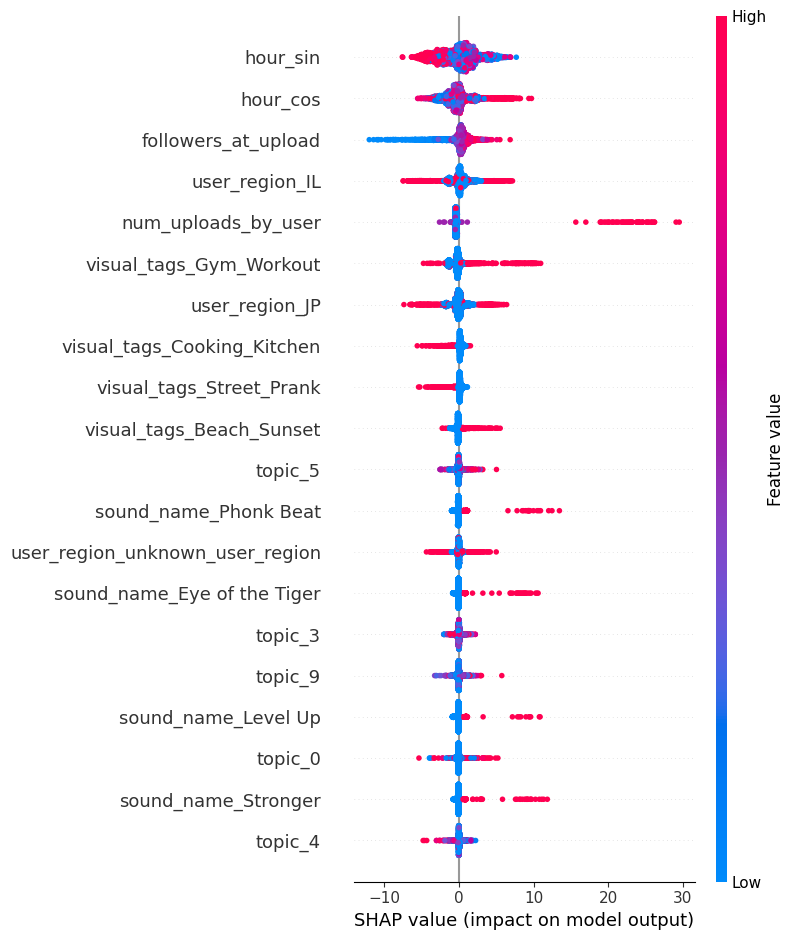

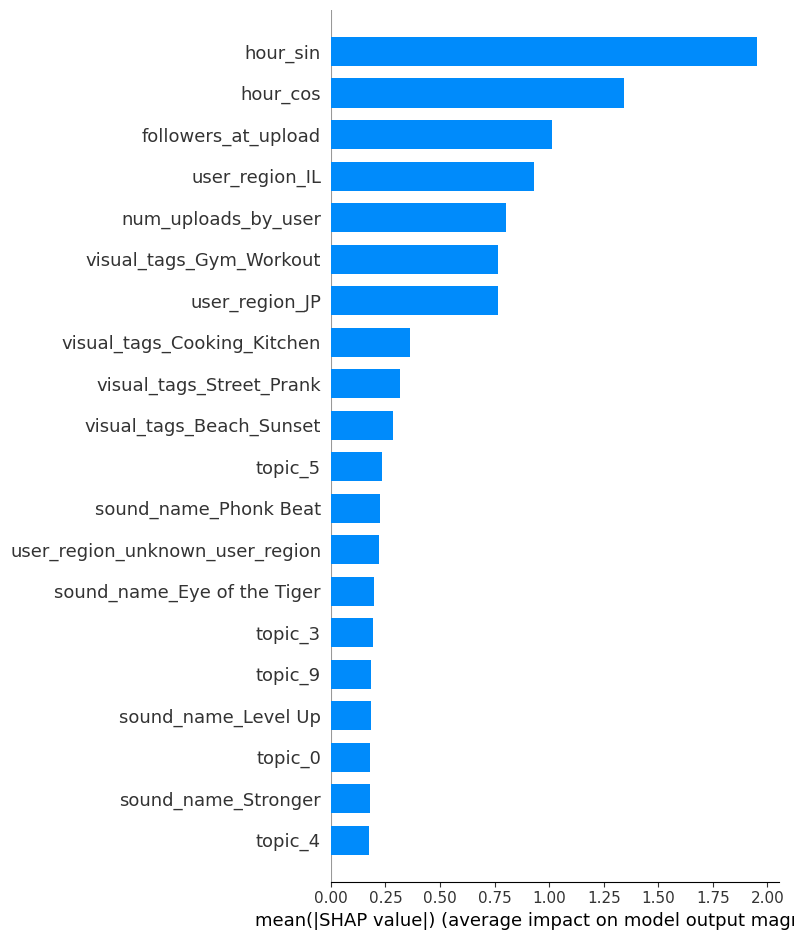

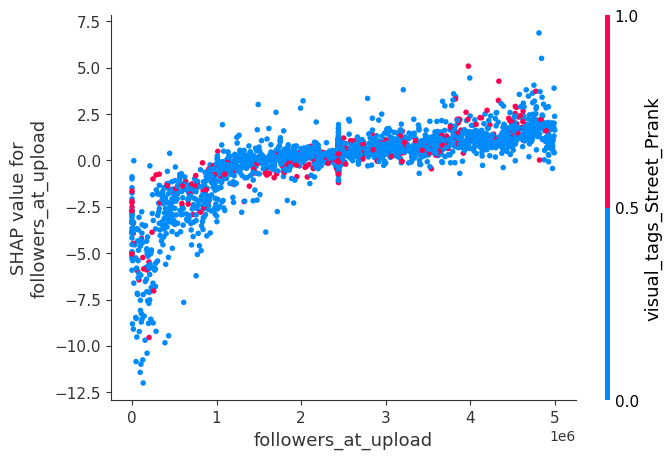

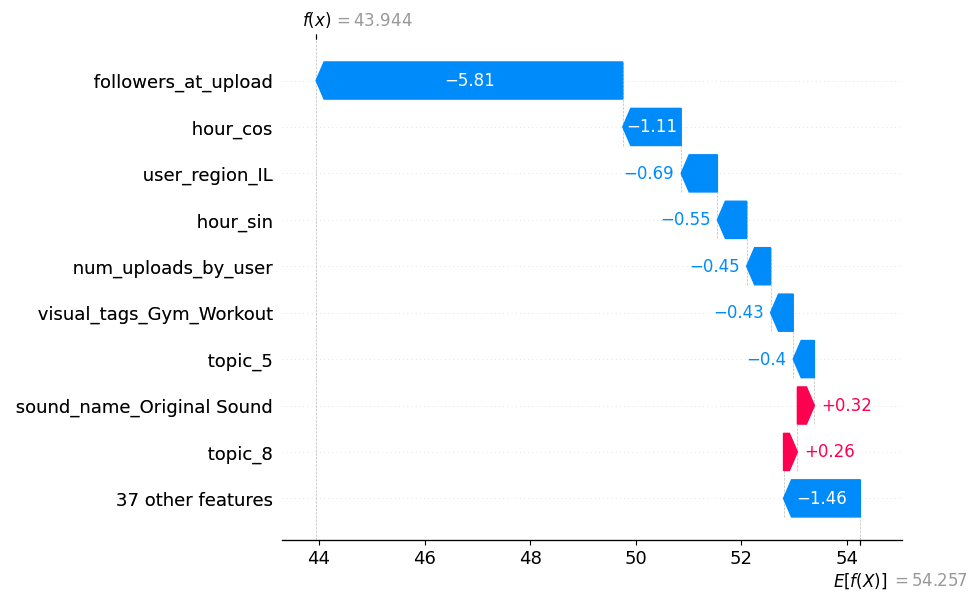

In [11]:
# Implement here
import shap

x_shap = x_validation

# Topics had no name in the processed data - we need to organize the features names before Shap
topic_feature_names = [f"topic_{i}" for i in range(10)]
categorical_feature_names = encoder.get_feature_names_out(["sound_name","visual_tags","user_region"]).tolist()
numeric_feature_names = ["followers_at_upload", "video_duration_sec", "hour_sin", "hour_cos", "day_sin", "day_cos", "num_uploads_by_user", "followers_at_upload_low_2_percent"]
feature_names = (numeric_feature_names +categorical_feature_names + topic_feature_names)

# Need to be dense for shap
x_shap_dense = x_shap.toarray() if hasattr(x_shap, "toarray") else np.array(x_shap)

# Define explainer and start
explainer = shap.TreeExplainer(best_tree)
shap_values = explainer.shap_values(x_shap_dense)

# Output1 : shap summary (Beeswarm): the features that most effect the prediction and the effect direction:
shap.summary_plot(shap_values, x_shap_dense, feature_names=feature_names)
print("\n")

# Output2 : shap summary (bar) : bar representation of each feature's effect on the prediction
shap.summary_plot(shap_values, x_shap_dense, plot_type="bar", feature_names=feature_names)
print("\n")


# Output3: shows for feature (we selected "followers_at_upload" how the feateru's value effects the prediction (shap value > 0: positive effect, shap value < 0: negative effect))
# shows another feature that has connection to the selected
shap.dependence_plot("followers_at_upload",shap_values,x_shap_dense,feature_names=feature_names
)

# Output4: waterflow for single sample: showing each feature's contributes to moving the prediction from the global expected (global virality_score mean of y_train):
i = 0 # ransom chooice of sample
shap.plots._waterfall.waterfall_legacy( explainer.expected_value[0],shap_values[i],x_shap_dense[i],feature_names=feature_names)



In [12]:
# 3 coclusions:
# 1.The mose influencing features are hour_sin and hour_cos (can see in the first and second outputs).
# It means that the most importand aspect for virality is the uploading hour.
# At output1, We can see red dots on the positive and negative side and that concludes great with our understanding that hours is a cyclic feature,
# and as we saw before, the pick of the effect is at 23 or 0 - it fits great to the output.

# 2. When Visual_tag = Gym_Workout, the prediction value is higher.
# We can see it in output1. there are red dots on the right side mainly, which means that the feature's higher value indicates higher predictions.
# in out case it is a binary feature created from categorical original feature, so the meaning is that the existense of Visual_tag = Gym_Workout makes the prediction higher.

#3. Conclusion — non-linear effect of followers_at_upload:
# The SHAP dependence plot for followers_at_upload reveals a strong non-linear relationship with the predicted virality score.
#Videos uploaded by users with very few followers receive a large negative contribution, while increasing follower counts lead to improving contribution to virality.
# note: although low follower counts generally reduce the predicted score, a small number of low-follower observations exhibit positive high SHAP values, indicating that under certain threshold the contribution of follower count can be very high.
# it connects to the insight we had before, that the lowest 2% of followers_at_upload have a large positive effect on virality score.


### Competition rank (5 pts):
The competition will be open until 4.1.26. The results of the competition will be published about 10 minutes  later under the private tab on the leaderboard.

The scoring of this section is relative to the location (between 0-5 pts).

Indicate here your team name in the competition and **attach an additinal notebook\python code** with which we can reproduce the rank you received.


In [13]:
# My team name was:BY_RA
# attached notebook: submission_for_kaggle.ipynb
